In [1]:
from cifar10.scripts import evaluate_model as ev


In [2]:
import torch
# Device
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: mps


In [3]:
ev._register_defaults()

In [4]:
from pathlib import Path
ROOT = Path.cwd().parent
checkpoint = ROOT / ".runs/own_wrn/checkpoints/best.pt"

In [5]:
ckpt = torch.load(
    checkpoint,
    map_location=device,
    weights_only=False,
)

In [6]:
model_id = "own_wrn"

In [7]:
# Reconstruct config
if "config" in ckpt:
    print("Using embedded config from checkpoint.")
    config = ev.reconstruct_config(ckpt["config"], model_id)
else:
    print("No embedded config found — using default config.")
    config_cls = ev.MODEL_REGISTRY[model_id][0]
    config = config_cls()

No embedded config found — using default config.


In [8]:
model = ev.MODEL_REGISTRY[model_id][1](config, device)
model.eval();

In [9]:

# Load weights (try EMA first, fall back to raw model)
if "ema" in ckpt:
    print("Loading EMA weights.")
    model.load_state_dict(ckpt["ema"])
else:
    print("Loading raw model weights.")
    model.load_state_dict(ckpt["model"])



Loading EMA weights.


In [10]:
class Args:
    def __init__(self):
        self.data_dir = ROOT / ".data"
        self.batch_size = 128
        self.num_workers = 0
args = Args()

In [11]:
# Build test loader (uses model-specific loader if registered)
test_loader = ev._build_test_loader(model_id, config, args, device)

In [12]:
for x, y in test_loader:

    x = x.to(device)
    y = y.to(device)

    with torch.no_grad():
        logits = model(x)
        preds = logits.argmax(dim=1)
        

In [13]:
# ---------------------------------------------------------------------------
# Build train / validation / test loaders using the project's profile-based
# loader factory.  The validation split is carved from the training set.
# ---------------------------------------------------------------------------
from cifar10.data.cifar10 import build_cifar10_loaders

train_loader, val_loader, tst_loader = build_cifar10_loaders(
    data_dir=args.data_dir,
    batch_size=args.batch_size,
    num_workers=args.num_workers,
    device=device,
    with_validation_split=True,
    validation_pct=0.1,
    augment=config.augment,
)

print(f"Train loader: {len(train_loader.dataset)} samples")
print(f"Valid loader: {len(val_loader.dataset)} samples")
print(f"Test  loader: {len(tst_loader.dataset)} samples")

Train loader: 45000 samples
Valid loader: 5000 samples
Test  loader: 10000 samples


In [14]:
# ---------------------------------------------------------------------------
# Collect misclassified samples
# ---------------------------------------------------------------------------
import math
import numpy as np
import torch.nn.functional as F
from collections import defaultdict

CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

# CIFAR10 normalisation constants (to denormalise images for display)
CIFAR10_MEAN = np.array([0.4914, 0.4822, 0.4465])
CIFAR10_STD  = np.array([0.2023, 0.1994, 0.2010])


def collect_misclassified(
    model: torch.nn.Module,
    loader: torch.utils.data.DataLoader,
    device: torch.device,
) -> dict:
    """Run inference on *loader* and return all misclassified samples.

    Returns a dict with keys:
        images:   numpy array of shape (N, 32, 32, 3) — denormalised uint8
        labels:   numpy array of ground-truth class indices
        preds:    numpy array of predicted class indices
        scores:   numpy array of softmax scores for the *predicted* class
        correct:  numpy array of bool — True for correctly classified
    """
    model.eval()

    all_images = []
    all_labels = []
    all_preds  = []
    all_scores = []
    all_correct = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        with torch.no_grad():
            logits = model(images)
            probs  = F.softmax(logits, dim=1)
            preds  = logits.argmax(dim=1)

        correct = preds == labels

        # Denormalise images: channel-wise (mean, std) → clip → uint8
        imgs_np = images.cpu().permute(0, 2, 3, 1).numpy()  # (B, H, W, C)
        imgs_np = imgs_np * CIFAR10_STD + CIFAR10_MEAN
        imgs_np = np.clip(imgs_np, 0, 1)

        all_images.append(imgs_np)
        all_labels.append(labels.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        # Gather the probability of the *predicted* class per sample
        batch_scores = probs.gather(1, preds.unsqueeze(1)).squeeze(1)
        all_scores.append(batch_scores.cpu().numpy())
        all_correct.append(correct.cpu().numpy())

    return {
        "images":  np.concatenate(all_images, axis=0),
        "labels":  np.concatenate(all_labels, axis=0),
        "preds":   np.concatenate(all_preds, axis=0),
        "scores":  np.concatenate(all_scores, axis=0),
        "correct": np.concatenate(all_correct, axis=0),
    }

In [15]:
# ---------------------------------------------------------------------------
# Run on all three splits
# ---------------------------------------------------------------------------
print("Collecting predictions on train split...")
train_results = collect_misclassified(model, train_loader, device)
print(f"  Total: {len(train_results['labels'])}  |  Misclassified: {(~train_results['correct']).sum()}")

print("Collecting predictions on valid split...")
val_results = collect_misclassified(model, val_loader, device)
print(f"  Total: {len(val_results['labels'])}  |  Misclassified: {(~val_results['correct']).sum()}")

print("Collecting predictions on test split...")
test_results = collect_misclassified(model, tst_loader, device)
print(f"  Total: {len(test_results['labels'])}  |  Misclassified: {(~test_results['correct']).sum()}")

  Total: 45000  |  Misclassified: 1470
  Total: 5000  |  Misclassified: 3
  Total: 10000  |  Misclassified: 341


In [49]:
# ---------------------------------------------------------------------------
# Helper: plot a grid of misclassified images
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt


def plot_misclassified_grid(
    results: dict,
    split_name: str,
    max_cols: int = 10,
    max_images: int | None = None,
    figsize: tuple[int, int] = None,
) -> None:
    """Plot a grid of misclassified images with prediction / GT / score."""
    mis_mask = ~results["correct"]
    mis_idx  = np.where(mis_mask)[0]

    if len(mis_idx) == 0:
        print(f"[{split_name}] No misclassified samples — perfect score!")
        return

    if max_images is not None:
        mis_idx = mis_idx[:max_images]
    
    n_images = len(mis_idx)
    n_cols   = min(max_cols, n_images)
    n_rows   = math.ceil(n_images / n_cols)

    figsize = (10, 2 * n_rows)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten() if n_rows * n_cols > 1 else [axes]

    for ax, idx in zip(axes, mis_idx):
        img  = results["images"][idx]
        gt   = results["labels"][idx]
        pred = results["preds"][idx]
        score = results["scores"][idx]

        ax.imshow(img)
        ax.axis("off")
        ax.set_title(
            f"{CIFAR10_CLASSES[pred]} {score:.2f}\n({CIFAR10_CLASSES[gt]})",
            fontsize=9,
        )

    # Turn off any unused axes
    for ax in axes[len(mis_idx):]:
        ax.axis("off")

    fig.suptitle(f"{split_name} — Misclassified samples ({len(mis_idx)} shown)", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

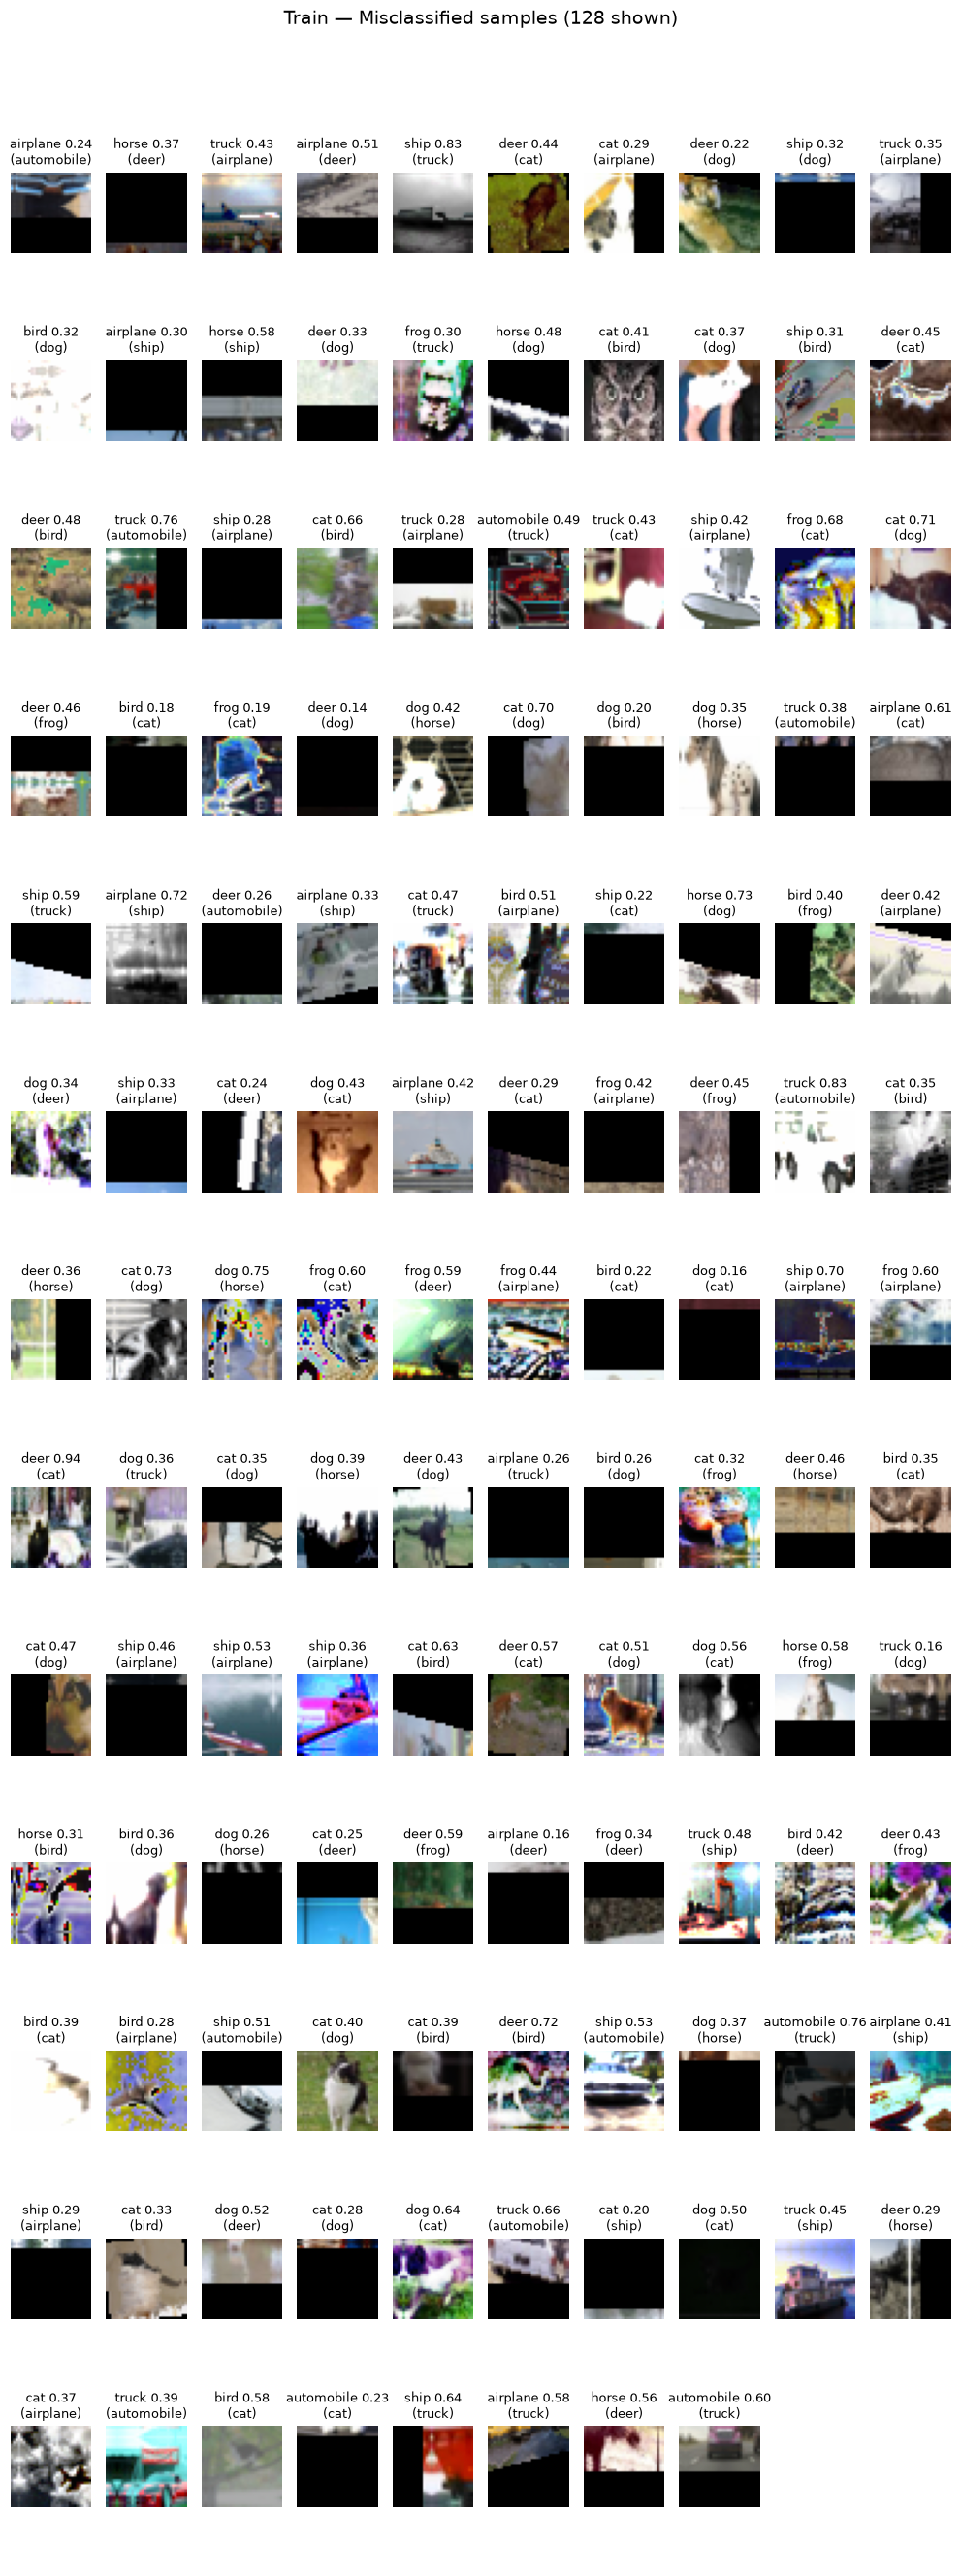

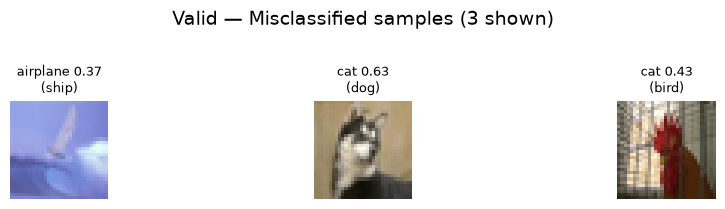

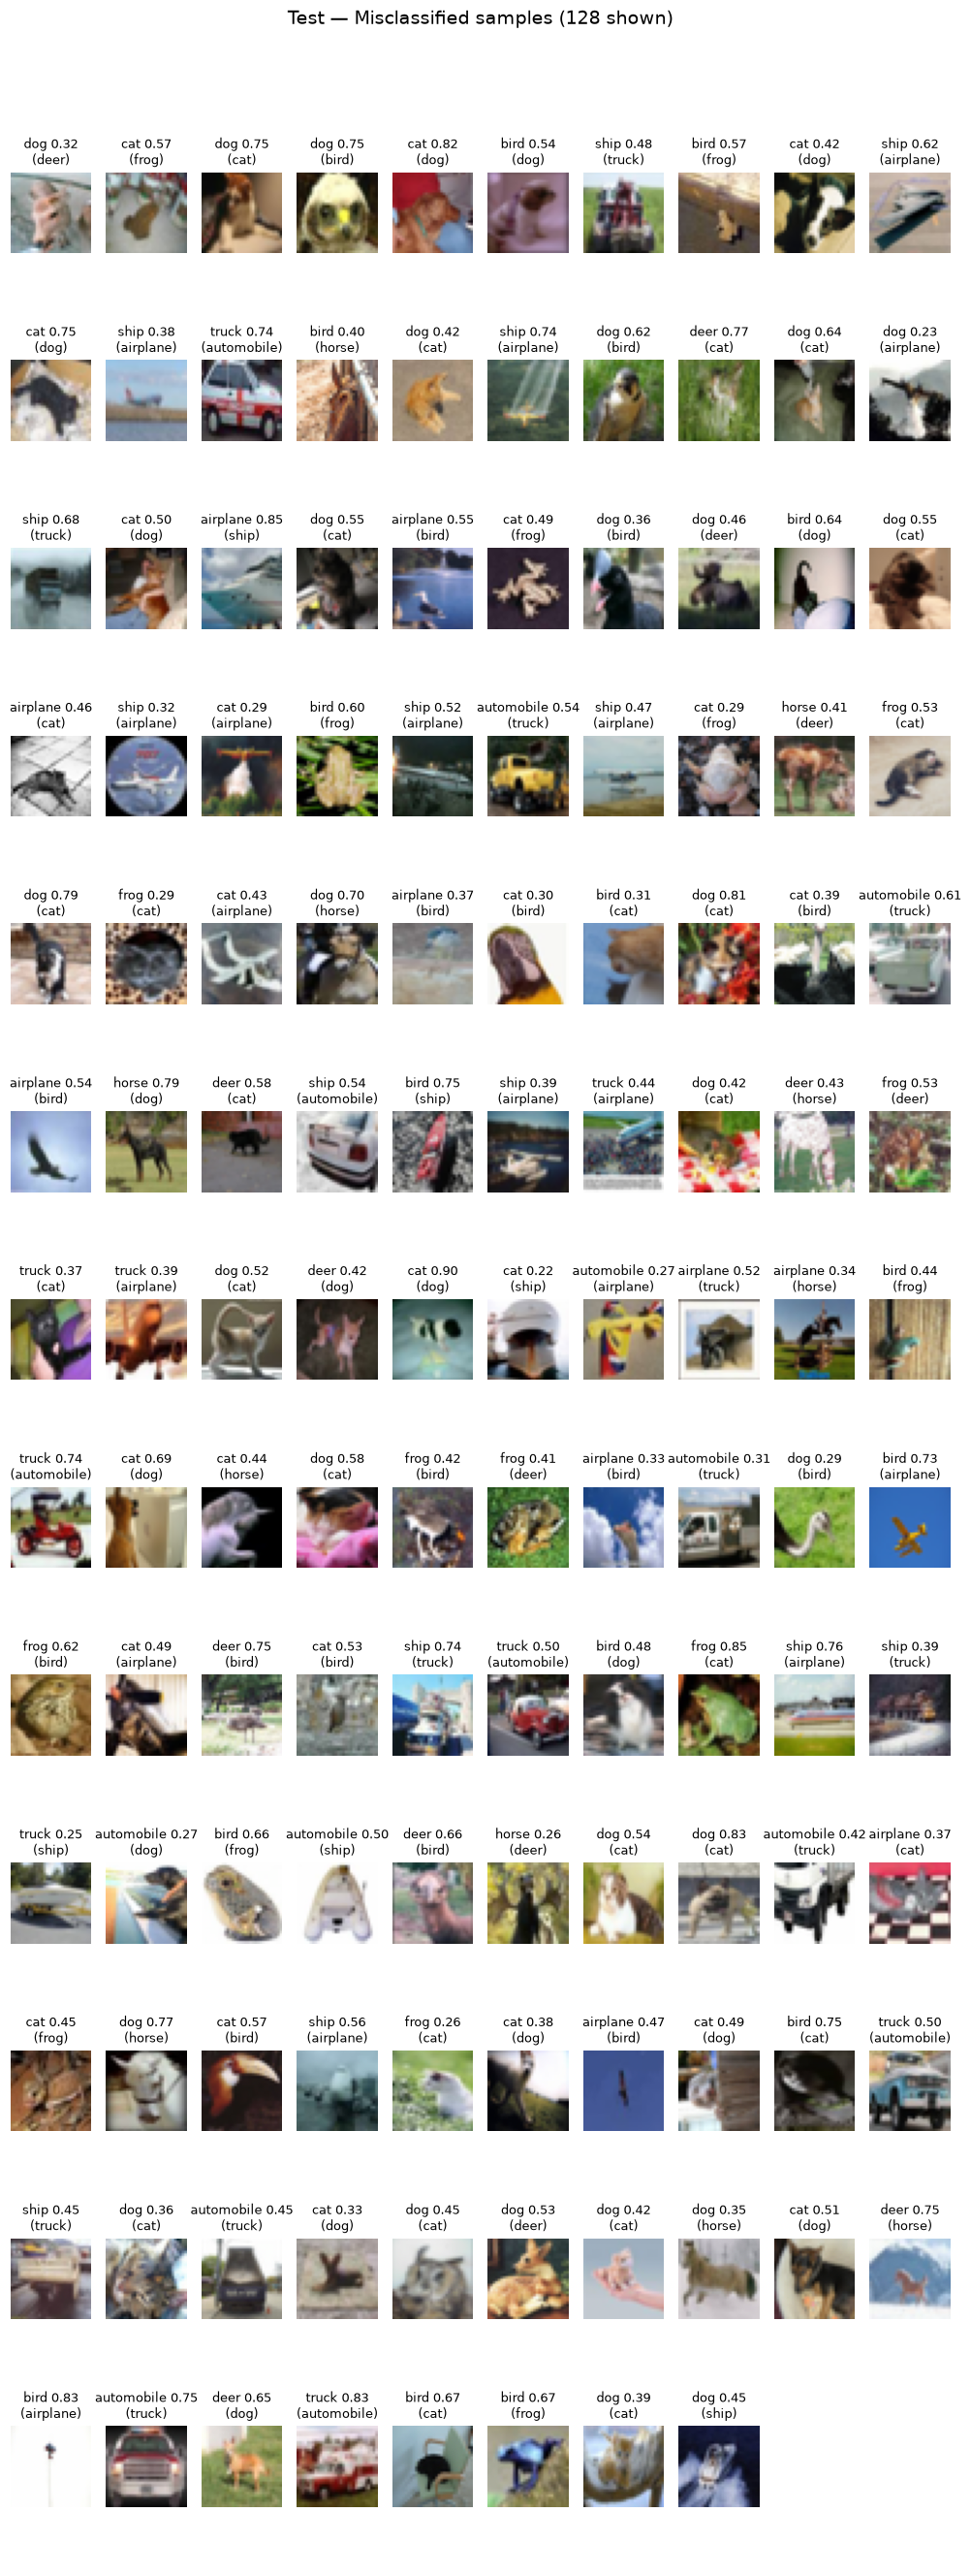

In [50]:
# ---------------------------------------------------------------------------
# Plot grids for train, valid, and test splits
# ---------------------------------------------------------------------------
plot_misclassified_grid(train_results, "Train", max_images=128)
plot_misclassified_grid(val_results,   "Valid", max_images=128)
plot_misclassified_grid(test_results,  "Test",  max_images=128)

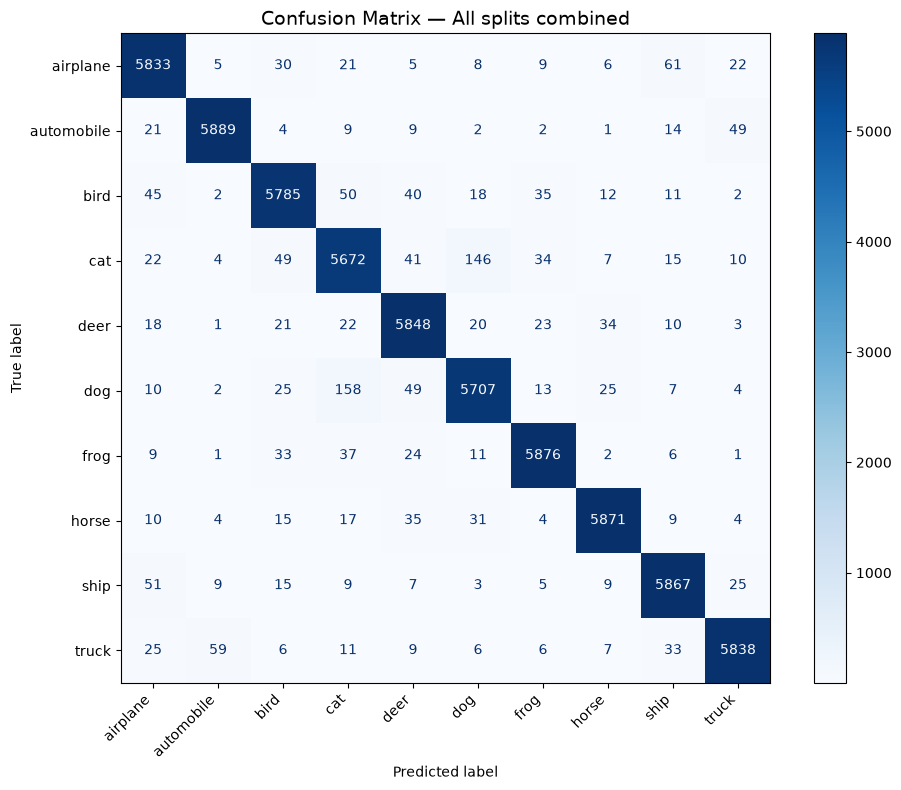

In [27]:
# ---------------------------------------------------------------------------
# Confusion matrix – aggregate over all splits to see most typical confusions
# ---------------------------------------------------------------------------
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Concatenate all predictions
all_labels = np.concatenate([
    train_results["labels"],
    val_results["labels"],
    test_results["labels"],
])
all_preds = np.concatenate([
    train_results["preds"],
    val_results["preds"],
    test_results["preds"],
])

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CIFAR10_CLASSES)
disp.plot(cmap="Blues", ax=ax, colorbar=True, values_format="d")
ax.set_title("Confusion Matrix — All splits combined", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [20]:
# ---------------------------------------------------------------------------
# Most frequent confusion pairs (off-diagonal)
# ---------------------------------------------------------------------------
# Zero out the diagonal so we only see misclassifications
np.fill_diagonal(cm, 0)

# Get sorted pairs by count
confusion_pairs = []
for gt in range(10):
    for pred in range(10):
        if cm[gt, pred] > 0:
            confusion_pairs.append((cm[gt, pred], gt, pred))

confusion_pairs.sort(reverse=True)

print("Top-10 most frequent misclassification pairs:")
print(f"{'GT':>12} → {'Pred':>12}   {'Count':>6}")
print("-" * 35)
for count, gt, pred in confusion_pairs[:10]:
    print(f"{CIFAR10_CLASSES[gt]:>12} → {CIFAR10_CLASSES[pred]:>12}   {count:>6}")

Top-10 most frequent misclassification pairs:
          GT →         Pred    Count
-----------------------------------
         dog →          cat      158
         cat →          dog      146
    airplane →         ship       61
       truck →   automobile       59
        ship →     airplane       51
        bird →          cat       50
         dog →         deer       49
         cat →         bird       49
  automobile →        truck       49
        bird →     airplane       45
